# TRYING ... can be deleted if did not work ... copy of v6.0
Doing the vertical integral of v*MSE first and then computed its divergent component

In [2]:
def mass_weighted_integral_simple(data, g=9.81):
    from scipy.integrate import simpson
    
    # Get pressure levels and convert to Pa
    plev = data.plev.values ;# * 100
    
    # REVERSE both data and pressure for integration (top to surface)
    plev_reversed = plev[::-1]  # Now ascending: 100, 200, ..., 1000
    
    data_filled = data.fillna(0.0)
    if hasattr(data_filled.data, 'compute'):
        data_filled = data_filled.compute()
    
    plev_axis = data.dims.index('plev')
    
    # Reverse data along pressure axis
    data_reversed = np.flip(data_filled.values, axis=plev_axis)
    
    # Integrate (now from low to high pressure)
    integrated = simpson(data_reversed, x=plev_reversed, axis=plev_axis)
    
    output_dims = [d for d in data.dims if d != 'plev']
    output_coords = {d: data[d] for d in output_dims}
    
    result = xr.DataArray(
        integrated / g,
        coords=output_coords,
        dims=output_dims
    )
    
    return result

In [3]:
def mass_weighted_integral_simple_with_ps(data, ps, g=9.81):
    """
    Mass-weighted vertical integral accounting for surface pressure.
    
    Parameters
    ----------
    data : xr.DataArray
        Data to integrate with dimensions (time, plev, lat, lon) or (plev, lat, lon)
    ps : xr.DataArray
        Surface pressure in Pa with dimensions (lat, lon) or (time, lat, lon)
    g : float
        Gravitational acceleration (m/s²)
    
    Returns
    -------
    xr.DataArray
        Vertically integrated data
    """
    from scipy.integrate import simpson
    import numpy as np
    
    # Get pressure levels in Pa
    plev = data.plev.values
    
    # Fill NaNs and compute if dask
    data_filled = data.fillna(0.0)
    if hasattr(data_filled.data, 'compute'):
        data_filled = data_filled.compute()
    
    # Ensure ps is on same grid as data
    ps_interp = ps.interp(lat=data.lat, lon=data.lon, method='linear')
    if hasattr(ps_interp.data, 'compute'):
        ps_interp = ps_interp.compute()
    
    # Find plev axis
    plev_axis = data.dims.index('plev')
    
    # Initialize output
    output_shape = list(data_filled.shape)
    output_shape.pop(plev_axis)
    integrated = np.zeros(output_shape)
    
    # Get axes for iteration
    if 'time' in data.dims:
        time_axis = data.dims.index('time')
        n_time = data.shape[time_axis]
    else:
        n_time = 1
        time_axis = None
    
    lat_axis = [i for i, d in enumerate(data.dims) if d == 'lat'][0]
    lon_axis = [i for i, d in enumerate(data.dims) if d == 'lon'][0]
    
    # Iterate over lat, lon (and time if present)
    for ilat in range(data.shape[lat_axis]):
        for ilon in range(data.shape[lon_axis]):
            
            if time_axis is not None:
                for itime in range(n_time):
                    # Get surface pressure for this point
                    if 'time' in ps_interp.dims:
                        ps_point = ps_interp.isel(time=itime, lat=ilat, lon=ilon).values
                    else:
                        ps_point = ps_interp.isel(lat=ilat, lon=ilon).values
                    
                    # Get profile
                    if time_axis == 0:
                        profile = data_filled.values[itime, :, ilat, ilon]
                    else:
                        profile = data_filled.values[:, itime, ilat, ilon]
                    
                    # Only integrate levels below surface
                    valid_levels = plev <= ps_point
                    if valid_levels.sum() > 1:
                        plev_valid = plev[valid_levels]
                        profile_valid = profile[valid_levels]
                        
                        # Reverse for integration (low to high pressure)
                        plev_rev = plev_valid[::-1]
                        profile_rev = profile_valid[::-1]
                        
                        # Integrate
                        result = simpson(profile_rev, x=plev_rev)
                        
                        if time_axis == 0:
                            integrated[itime, ilat, ilon] = result / g
                        else:
                            integrated[ilat, ilon, itime] = result / g
            else:
                # No time dimension
                ps_point = ps_interp.isel(lat=ilat, lon=ilon).values
                profile = data_filled.values[:, ilat, ilon]
                
                # Only integrate levels below surface
                valid_levels = plev <= ps_point
                if valid_levels.sum() > 1:
                    plev_valid = plev[valid_levels]
                    profile_valid = profile[valid_levels]
                    
                    # Reverse for integration
                    plev_rev = plev_valid[::-1]
                    profile_rev = profile_valid[::-1]
                    
                    # Integrate
                    integrated[ilat, ilon] = simpson(profile_rev, x=plev_rev) / g
    
    # Create output DataArray
    output_dims = [d for d in data.dims if d != 'plev']
    output_coords = {d: data[d] for d in output_dims}
    
    result = xr.DataArray(
        integrated,
        coords=output_coords,
        dims=output_dims
    )
    
    return result

In [4]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from windspharm.standard import VectorWind
import cftime

In [5]:
# ----------------------------
# CONSTANTS
# ----------------------------
Cp = 1004.0        # J kg-1 K-1
Lv = 2.5e6         # J kg-1
g  = 9.81          # m s-2
R  = 6.371e6       # Earth radius (m)

In [6]:
ds_t = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/ta/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("T in units of K",ds_t)

ds_q = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/hus/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("q in units of 1",ds_q)

ds_z = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/zg/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("z in unit of meter",ds_z)

ds_u = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/ua/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("u in unit of meter/sec",ds_u)

ds_v = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/va/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

ds_ps = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/ps/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

In [7]:
ta_mean = ds_t.ta.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
q_mean  = ds_q.hus.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
z_mean  = ds_z.zg.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
u_mean  = ds_u.ua.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
v_mean  = ds_v.va.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000)) ;#.mean("time")
ps_mean  = ds_ps.ps.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))

In [8]:
ta_mean=ta_mean.mean("time")
q_mean=q_mean.mean("time")
z_mean=z_mean.mean("time")
u_mean=u_mean.mean("time")
v_mean=v_mean.mean("time")
ps_mean=ps_mean.mean("time")

In [9]:
ps_mean

<xarray.DataArray 'ps' (lat: 144, lon: 192)> Size: 111kB
dask.array<mean_agg-aggregate, shape=(144, 192), dtype=float32, chunksize=(144, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1

In [10]:
# Use RAW winds (no barotropic correction)
u_filled = u_mean.fillna(0.0)
v_filled = v_mean.fillna(0.0)

# Compute MSE
h = Cp * ta_mean + Lv * q_mean + g * z_mean
h_on_u = h.interp(lat=u_filled.lat, lon=u_filled.lon, method='linear')
h_on_v = h.interp(lat=v_filled.lat, lon=v_filled.lon, method='linear')

# MSE fluxes
uh = u_filled * h_on_u
vh = v_filled * h_on_v

# Vertical integration
uh_int = mass_weighted_integral_simple_with_ps(uh, ps_mean, g=9.81) ;#include information of ps
vh_int = mass_weighted_integral_simple_with_ps(vh, ps_mean, g=9.81) ;#include information of ps

# Compute divergent component
vw = VectorWind(uh_int, vh_int)
Flambda_div, Fphi_div =  vw.irrotationalcomponent()

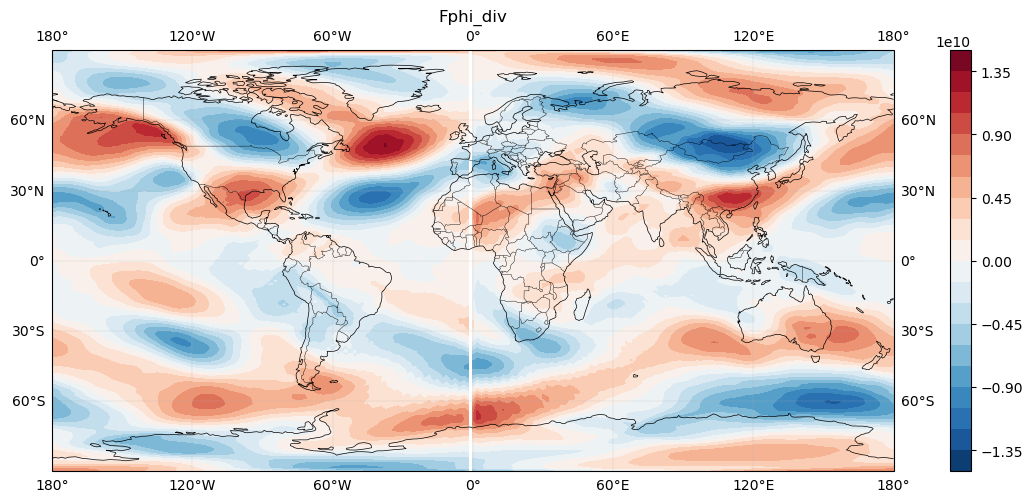

In [11]:
# Select a time index (e.g., month 0 = January)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Fphi_div = xr.DataArray(Fphi_div, dims=vh_int.dims, coords=vh_int.coords)
v=Fphi_div

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



# SMOOTH APPROACH

In [15]:
#Reading the data again since the smooth approach smooths the data at every time step and earlier I had averaged over time

ta_mean = ds_t.ta.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
q_mean  = ds_q.hus.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
z_mean  = ds_z.zg.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
u_mean  = ds_u.ua.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))
v_mean  = ds_v.va.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000)) ;#.mean("time")
ps_mean  = ds_ps.ps.sel(time=slice("2001-01-01", "2001-12")) ;#,plev=slice(50000,10000))

## OPTION#1

In [13]:
# from scipy.ndimage import gaussian_filter

# ta_mean=ta_mean.mean("time")
# q_mean=q_mean.mean("time")
# z_mean=z_mean.mean("time")
# u_mean=u_mean.mean("time")
# v_mean=v_mean.mean("time")
# ps_mean=ps_mean.mean("time")

# # Use RAW winds (no barotropic correction)
# u_filled = u_mean.fillna(0.0)
# v_filled = v_mean.fillna(0.0)

# # Compute MSE
# h = Cp * ta_mean + Lv * q_mean + g * z_mean
# h_on_u = h.interp(lat=u_filled.lat, lon=u_filled.lon, method='linear')
# h_on_v = h.interp(lat=v_filled.lat, lon=v_filled.lon, method='linear')

# # MSE fluxes
# uh = u_filled * h_on_u
# vh = v_filled * h_on_v

# # Vertical integration
# # uh_int = -mass_weighted_integral_simple(uh, g=9.81)  # Note the negative sign!
# # vh_int = -mass_weighted_integral_simple(vh, g=9.81)
# uh_int = -mass_weighted_integral_simple_with_ps(uh, ps_mean, g=9.81) ;#include information of ps
# vh_int = -mass_weighted_integral_simple_with_ps(vh, ps_mean, g=9.81) ;#include information of ps

# # **SMOOTH before computing divergent component**
# sigma = 3  # Smoothing strength (adjust 2-5)

# uh_int_smooth = xr.apply_ufunc(
#     gaussian_filter,
#     uh_int,
#     kwargs={'sigma': sigma},
#     input_core_dims=[['lat', 'lon']],
#     output_core_dims=[['lat', 'lon']],
#     vectorize=True
# )

# vh_int_smooth = xr.apply_ufunc(
#     gaussian_filter,
#     vh_int,
#     kwargs={'sigma': sigma},
#     input_core_dims=[['lat', 'lon']],
#     output_core_dims=[['lat', 'lon']],
#     vectorize=True
# )

# # Compute divergent component on smoothed fields
# vw = VectorWind(uh_int_smooth, vh_int_smooth)
# Flambda_div, Fphi_div = vw.irrotationalcomponent()

## OPTION#2

In [11]:
# from scipy.ndimage import gaussian_filter

# # Use RAW winds (no barotropic correction)
# u_filled = u_mean.fillna(0.0)
# v_filled = v_mean.fillna(0.0)

# # Compute MSE
# h = Cp * ta_mean + Lv * q_mean + g * z_mean
# h_on_u = h.interp(lat=u_filled.lat, lon=u_filled.lon, method='linear')
# h_on_v = h.interp(lat=v_filled.lat, lon=v_filled.lon, method='linear')

# # MSE fluxes
# uh = u_filled * h_on_u
# vh = v_filled * h_on_v

# # Vertical integration
# uh_int = -mass_weighted_integral_simple(uh, g=9.81)
# vh_int = -mass_weighted_integral_simple(vh, g=9.81)

# # Regrid to CDS fine grid (0.25°)
# target_lat = np.arange(90, -90.25, -0.25)  # Descending
# target_lon = np.arange(0, 360, 0.25)

# uh_regrid = uh_int.interp(lat=target_lat, lon=target_lon, method='linear')
# vh_regrid = vh_int.interp(lat=target_lat, lon=target_lon, method='linear')

# # Compute divergent component monthly, then average
# Fphi_div_list = []

# for t in range(len(uh_regrid.time)):
#     u_t = uh_regrid.isel(time=t).fillna(0.0)
#     v_t = vh_regrid.isel(time=t).fillna(0.0)
    
#     vw = VectorWind(u_t, v_t)
#     _, v_div = vw.irrotationalcomponent()
    
#     Fphi_div_list.append(v_div)

# Fphi_div = xr.concat(Fphi_div_list, dim='time').mean(dim='time')

## OPTION#3 (combination of 1 and 2)

In [16]:
from scipy.ndimage import gaussian_filter

# Use RAW winds (no barotropic correction)
u_filled = u_mean.fillna(0.0)
v_filled = v_mean.fillna(0.0)

# Compute MSE
h = Cp * ta_mean + Lv * q_mean + g * z_mean
h_on_u = h.interp(lat=u_filled.lat, lon=u_filled.lon, method='linear')
h_on_v = h.interp(lat=v_filled.lat, lon=v_filled.lon, method='linear')

# MSE fluxes
uh = u_filled * h_on_u
vh = v_filled * h_on_v

# Vertical integration
# uh_int = -mass_weighted_integral_simple(uh, g=9.81)  # Note the negative sign!
# vh_int = -mass_weighted_integral_simple(vh, g=9.81)
uh_int = -mass_weighted_integral_simple_with_ps(uh, ps_mean, g=9.81) ;#include information of ps
vh_int = -mass_weighted_integral_simple_with_ps(vh, ps_mean, g=9.81) ;#include information of ps

# 1. Regrid to finer resolution
target_lat = np.arange(90, -90.5, -0.5)  # 0.5° resolution
target_lon = np.arange(0, 360, 0.5)

uh_regrid = uh_int.interp(lat=target_lat, lon=target_lon, method='linear')
vh_regrid = vh_int.interp(lat=target_lat, lon=target_lon, method='linear')

# 2. Apply light smoothing
sigma = 2

uh_smooth = xr.apply_ufunc(
    gaussian_filter, uh_regrid,
    kwargs={'sigma': sigma},
    input_core_dims=[['lat', 'lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True
)

vh_smooth = xr.apply_ufunc(
    gaussian_filter, vh_regrid,
    kwargs={'sigma': sigma},
    input_core_dims=[['lat', 'lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True
)

# 3. Compute divergent component monthly, then average
# Fphi_div_list = []
# for t in range(len(uh_smooth.time)):
#     vw = VectorWind(uh_smooth.isel(time=t).fillna(0.0), 
#                     vh_smooth.isel(time=t).fillna(0.0))
#     _, v_div = vw.irrotationalcomponent()
#     Fphi_div_list.append(v_div)

# Fphi_div = xr.concat(Fphi_div_list, dim='time').mean(dim='time')

Fphi_div_list = []

for t in range(len(uh_smooth.time)):
    vw = VectorWind(
        uh_smooth.isel(time=t).fillna(0.0),
        vh_smooth.isel(time=t).fillna(0.0)
    )

    _, v_div = vw.irrotationalcomponent()

    # Convert numpy array → xarray DataArray
    v_div_da = xr.DataArray(
        v_div,
        coords={"lat": uh_smooth.lat, "lon": uh_smooth.lon},
        dims=("lat", "lon")
    )

    Fphi_div_list.append(v_div_da)

Fphi_div = xr.concat(Fphi_div_list, dim="time")
Fphi_div = Fphi_div.assign_coords(time=uh_smooth.time)
Fphi_div = Fphi_div.mean(dim="time")

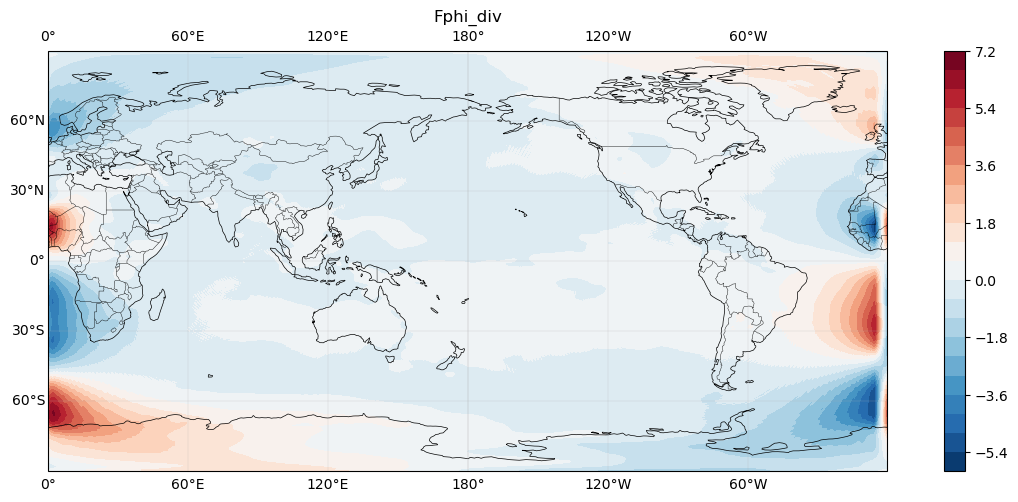

In [29]:
# Select a time index (e.g., month 0 = January)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Fphi_div = xr.DataArray(Fphi_div, dims=vh_int.dims, coords=vh_int.coords)
v=Fphi_div/10e8

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(180)}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [14]:
from windspharm.standard import VectorWind
import numpy as np

def windspharm_time_loop(uh_int, vh_int):
    """
    Compute divergent component using VectorWind on raw numpy arrays.
    """
    Flambda_div_list = []
    Fphi_div_list = []
    
    for t in range(uh_int.time.size):
        # Extract single time step as NUMPY ARRAYS
        u_t = uh_int.isel(time=t).values  # Convert to numpy
        v_t = vh_int.isel(time=t).values  # Convert to numpy
        
        # Fill any remaining NaNs
        u_t = np.nan_to_num(u_t, nan=0.0)
        v_t = np.nan_to_num(v_t, nan=0.0)
        
        # VectorWind expects (lat, lon) numpy arrays
        vw = VectorWind(u_t, v_t)
        u_div, v_div = vw.divergentcomponent()
        
        # Convert back to xarray with proper coordinates
        Flambda_div_list.append(xr.DataArray(
            u_div, 
            coords={"lat": uh_int.lat, "lon": uh_int.lon}, 
            dims=("lat", "lon")
        ))
        Fphi_div_list.append(xr.DataArray(
            v_div, 
            coords={"lat": uh_int.lat, "lon": uh_int.lon}, 
            dims=("lat", "lon")
        ))
    
    # Concatenate along time
    Flambda_div = xr.concat(Flambda_div_list, dim="time").assign_coords(time=uh_int.time)
    Fphi_div = xr.concat(Fphi_div_list, dim="time").assign_coords(time=vh_int.time)
    
    return Flambda_div, Fphi_div

In [15]:
# def mass_weighted_integral_simple(data, g=9.81):
#     """
#     Simple mass-weighted integral using composite Simpson's rule.
    
#     Parameters
#     ----------
#     data : xr.DataArray
#         Data to integrate (time, plev, lat, lon)
#     g : float
#         Gravity (m/s²)
    
#     Returns
#     -------
#     xr.DataArray
#         Vertically integrated data
#     """
#     from scipy.integrate import simpson
    
#     # Get pressure levels
#     plev = data.plev.values
    
#     # Fill NaNs
#     data_filled = data.fillna(0.0)
    
#     # Load data if it's a dask array (to avoid dask issues)
#     if hasattr(data_filled.data, 'compute'):
#         data_filled = data_filled.compute()
    
#     # Use scipy.integrate.simpson
#     # Find which axis is 'plev'
#     plev_axis = data.dims.index('plev')
    
#     # Integrate using Simpson's rule
#     integrated = simpson(data_filled.values, x=plev, axis=plev_axis)
    
#     # Create output DataArray
#     output_dims = [d for d in data.dims if d != 'plev']
#     output_coords = {d: data[d] for d in output_dims}
    
#     result = xr.DataArray(
#         integrated / g,
#         coords=output_coords,
#         dims=output_dims
#     )
    
#     return result


def mass_weighted_integral_simple(data, g=9.81):
    """
    Simple mass-weighted integral using composite Simpson's rule.
    """
    from scipy.integrate import simpson
    
    # Get pressure levels
    plev = data.plev.values
    
    # Fill NaNs
    data_filled = data.fillna(0.0)
    
    # Load data if it's a dask array
    if hasattr(data_filled.data, 'compute'):
        data_filled = data_filled.compute()
    
    # Find which axis is 'plev'
    plev_axis = data.dims.index('plev')
    
    print(f"Integration: plev_axis={plev_axis}, data shape={data_filled.shape}")
    
    # Integrate using Simpson's rule
    integrated = simpson(data_filled.values, x=plev, axis=plev_axis)
    
    print(f"After integration: shape={integrated.shape}")
    
    # Create output DataArray with ALL remaining dimensions
    output_dims = list(data.dims)
    output_dims.remove('plev')
    
    output_coords = {d: data.coords[d] for d in output_dims}
    
    print(f"Output dims: {output_dims}")
    print(f"Output coords keys: {list(output_coords.keys())}")
    
    result = xr.DataArray(
        integrated / g,
        coords=output_coords,
        dims=output_dims
    )
    
    return result

In [16]:
import numpy as np
import xarray as xr
# our local module:
import itcz

import matplotlib as mpl
import matplotlib.pyplot as plt

In [17]:
import xarray as xr
from pathlib import Path
import myfunctions as mf

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
# from xarrayutils import divergence_spherical, helmholtz_decomposition_spectral  # placeholder functions

In [19]:
ds_n = xr.open_dataset("/home/users/bidyut/UoE/20260112_Basic_Analysis/cds.climate.copernicus.eu/latent-heat-flux-northward_monthly_202201_v1.0.nc")

ds_n

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-01-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    lhfln      (time, latitude, longitude) float32 4MB ...
Attributes:
    Conventions:  CF-1.6
    version:      v1.0

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windspharm.standard import VectorWind
import cftime
import mse_divergence


# ######################
# def windspharm_time_loop(u, v, method="divergentcomponent"):

#     out1_list = []
#     out2_list = []

#     for t in range(u.time.size):
#         vw = VectorWind(u.isel(time=t), v.isel(time=t))
#         out1, out2 = getattr(vw, method)()

#         out1_list.append(xr.DataArray(out1, coords={"lat": u.lat, "lon": u.lon}, dims=("lat","lon")))
#         out2_list.append(xr.DataArray(out2, coords={"lat": u.lat, "lon": u.lon}, dims=("lat","lon")))

#     out1 = xr.concat(out1_list, dim="time").assign_coords(time=u.time)
#     out2 = xr.concat(out2_list, dim="time").assign_coords(time=u.time)

#     return out1, out2

# ----------------------------
# Helper: convert integer years to cftime slice
# ----------------------------
def year_slice_to_cftime(da, start_year, end_year):
    """Convert integer years to cftime slice for a DataArray"""
    start = cftime.Datetime360Day(start_year, 1, 1)
    end   = cftime.Datetime360Day(end_year, 12, 30)
    return slice(start, end)
    

ds_t = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/ta/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("T in units of K",ds_t)

ds_q = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/hus/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("q in units of 1",ds_q)

ds_z = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/zg/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("z in unit of meter",ds_z)

ds_u = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/ua/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("u in unit of meter/sec",ds_u)

ds_v = xr.open_mfdataset(
    "/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/va/gn/latest/*.nc",
    combine="by_coords", parallel=True, decode_times=True, use_cftime=True)

# print("v in unit of meter/sec",ds_v)
######################



# ----------------------------
# CONSTANTS
# ----------------------------
Cp = 1004.0        # J kg-1 K-1
Lv = 2.5e6         # J kg-1
g  = 9.81          # m s-2
R  = 6.371e6       # Earth radius (m)

# ----------------------------
# BLOCK 1: READING VARIABLES (lat,lon,lev,time)
# ----------------------------

start_year = 2071
end_year   = 2101 ;# These are not used at the moment since I am testing with historical run

ta_mean = ds_t.ta.sel(time=slice("2001-01-01", "2001-12"),plev=slice(50000,10000))
q_mean  = ds_q.hus.sel(time=slice("2001-01-01", "2001-12"),plev=slice(50000,10000))
z_mean  = ds_z.zg.sel(time=slice("2001-01-01", "2001-12"),plev=slice(50000,10000))
u_mean  = ds_u.ua.sel(time=slice("2001-01-01", "2001-12"),plev=slice(50000,10000))
v_mean  = ds_v.va.sel(time=slice("2001-01-01", "2001-12"),plev=slice(50000,10000)) ;#.mean("time")


# Use RAW winds (no barotropic correction)
u_filled = u_mean.fillna(0.0)
v_filled = v_mean.fillna(0.0)

# Compute MSE
h = Cp * ta_mean + Lv * q_mean + g * z_mean

# CRITICAL: Interpolate h to match u/v grid
h_on_u = h.interp(lat=u_filled.lat, lon=u_filled.lon, method='linear')
h_on_v = h.interp(lat=v_filled.lat, lon=v_filled.lon, method='linear')

print("After interpolation:")
print("u_filled shape:", u_filled.shape)
print("h_on_u shape:", h_on_u.shape)
print("v_filled shape:", v_filled.shape)
print("h_on_v shape:", h_on_v.shape)

# MSE fluxes
uh = u_filled * h_on_u
vh = v_filled * h_on_v

print("\nuh shape:", uh.shape)
print("vh shape:", vh.shape)

# Vertical integration (Simpson's rule)
uh_int = mass_weighted_integral_simple(uh, g=9.81)
vh_int = mass_weighted_integral_simple(vh, g=9.81)

# Compute divergent component
Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

#=================================================================
# # Use RAW winds (no barotropic correction)
# u_filled = u_mean.fillna(0.0)
# v_filled = v_mean.fillna(0.0)

# # Compute MSE (not total energy - skip kinetic for now)
# h = Cp * ta_mean + Lv * q_mean + g * z_mean
# h_on_v = h  # If same grid

# # MSE fluxes
# uh = u_filled * h_on_v
# vh = v_filled * h_on_v

# # Vertical integration (Simpson's rule)
# uh_int = mass_weighted_integral_simple(uh, g=9.81)
# vh_int = mass_weighted_integral_simple(vh, g=9.81)

# # Compute divergent component
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)


#=================================================================

# # Regrid to CDS grid
# uh_int_regrid = uh_int.interp(lat=ds_n.latitude.values, lon=ds_n.longitude.values)
# vh_int_regrid = vh_int.interp(lat=ds_n.latitude.values, lon=ds_n.longitude.values)

# # Sort descending
# uh_int_regrid = uh_int_regrid.sortby('lat', ascending=False)
# vh_int_regrid = vh_int_regrid.sortby('lat', ascending=False)

# # Sort descending
# uh_int = uh_int.sortby('lat', ascending=False)
# vh_int = vh_int.sortby('lat', ascending=False)

# # Compute divergent component
# # Flambda_div, Fphi_div = windspharm_time_loop(uh_int_regrid, vh_int_regrid)
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)



After interpolation:
u_filled shape: (12, 7, 145, 192)
h_on_u shape: (12, 7, 145, 192)
v_filled shape: (12, 7, 145, 192)
h_on_v shape: (12, 7, 145, 192)

uh shape: (12, 7, 145, 192)
vh shape: (12, 7, 145, 192)
Integration: plev_axis=1, data shape=(12, 7, 145, 192)
After integration: shape=(12, 145, 192)
Output dims: ['time', 'lat', 'lon']
Output coords keys: ['time', 'lat', 'lon']
Integration: plev_axis=1, data shape=(12, 7, 145, 192)
After integration: shape=(12, 145, 192)
Output dims: ['time', 'lat', 'lon']
Output coords keys: ['time', 'lat', 'lon']


In [21]:
# First, check what uh_int and vh_int actually look like
print("uh_int dimensions:", uh_int.dims)
print("uh_int shape:", uh_int.shape)
print("vh_int dimensions:", vh_int.dims)
print("vh_int shape:", vh_int.shape)

# Check a single time slice
print("\nSingle time slice:")
print("uh_int[0] shape:", uh_int.isel(time=0).shape)
print("uh_int[0] values shape:", uh_int.isel(time=0).values.shape)

uh_int dimensions: ('time', 'lat', 'lon')
uh_int shape: (12, 145, 192)
vh_int dimensions: ('time', 'lat', 'lon')
vh_int shape: (12, 145, 192)

Single time slice:
uh_int[0] shape: (145, 192)
uh_int[0] values shape: (145, 192)


In [22]:
# # Debug the integration
# print("Before integration:")
# print("uh shape:", uh.shape)
# print("uh dims:", uh.dims)
# print("uh coords:", list(uh.coords.keys()))

# print("\nCalling mass_weighted_integral_simple...")
# uh_int = mass_weighted_integral_simple(uh, g=9.81)

# print("\nAfter integration:")
# print("uh_int shape:", uh_int.shape)
# print("uh_int dims:", uh_int.dims)
# print("uh_int coords:", list(uh_int.coords.keys()))

In [23]:
print("u_filled shape:", u_filled.shape)
print("u_filled dims:", u_filled.dims)
print("u_filled coords:", list(u_filled.coords.keys()))

print("\nh shape:", h.shape)
print("h dims:", h.dims)
print("h coords:", list(h.coords.keys()))

print("\nh_on_v shape:", h_on_v.shape)
print("h_on_v dims:", h_on_v.dims)
print("h_on_v coords:", list(h_on_v.coords.keys()))

print("\nuh = u_filled * h_on_v")
print("uh shape:", uh.shape)
print("uh dims:", uh.dims)

u_filled shape: (12, 7, 145, 192)
u_filled dims: ('time', 'plev', 'lat', 'lon')
u_filled coords: ['time', 'plev', 'lat', 'lon']

h shape: (12, 7, 144, 192)
h dims: ('time', 'plev', 'lat', 'lon')
h coords: ['time', 'plev', 'lat', 'lon']

h_on_v shape: (12, 7, 145, 192)
h_on_v dims: ('time', 'plev', 'lat', 'lon')
h_on_v coords: ['time', 'plev', 'lat', 'lon']

uh = u_filled * h_on_v
uh shape: (12, 7, 145, 192)
uh dims: ('time', 'plev', 'lat', 'lon')


In [24]:
# Regrid using xarray's interp
# uh_int_regrid = uh_int.interp(lat=target_lat, lon=target_lon, method='linear')

In [25]:
# vh_int_regrid = vh_int.interp(lat=target_lat, lon=target_lon, method='linear')


In [26]:


# # # # CDS data has ASCENDING latitude (-90 to 90), but VectorWind needs DESCENDING (90 to -90)
# # # # So reverse the latitude
# # # uh_int_regrid = uh_int_regrid.sortby('lat', ascending=False)
# # # vh_int_regrid = vh_int_regrid.sortby('lat', ascending=False)

# # print("\nAfter regridding:")
# # print("  uh_int_regrid lat:", uh_int_regrid.lat.values[:5], "...", uh_int_regrid.lat.values[-5:])
# # print("  Shape:", uh_int_regrid.shape)

# # Now compute divergent component on the CDS grid
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

# print("\nFphi_div range:", Fphi_div.min().values, "to", Fphi_div.max().values)




# # # Make sure latitude is descending for VectorWind
# # if uh_int_regrid.lat.values[0] < uh_int_regrid.lat.values[-1]:
# #     uh_int_regrid = uh_int_regrid.sortby('lat', ascending=False)
# #     vh_int_regrid = vh_int_regrid.sortby('lat', ascending=False)

# # # Now compute divergent component on the regular grid
# # Flambda_div, Fphi_div = windspharm_time_loop(uh_int_regrid.fillna(0.0), vh_int_regrid.fillna(0.0))

# # print("After regridding:")
# # print("Fphi_div range:", Fphi_div.min().values, "to", Fphi_div.max().values)


# # # # Then compute divergent component
# # # Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)



# # # ----------------------------
# # # BLOCK 4 : COMPUTE INTEGRAL (lat,lon,time)
# # # ----------------------------
# # # Computing (1/g) ∫ v dp
# # # uh_int = (uh_clean * dp / g).sum("plev")
# # # vh_int = (vh_clean * dp / g).sum("plev")
# # # CORRECT version
# # uh_int = (uh_clean * dp).sum("plev") / g
# # vh_int = (vh_clean * dp).sum("plev") / g

# # # ----------------------------
# # # BLOCK 5 : GET h_DIV (lat,lon,time)
# # # ----------------------------
# # Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

# Fphi_div.name = "Fphi_div"
# Fphi_div.attrs["long_name"] = "divergent meridional MSE flux"
# Fphi_div.attrs["units"] = "W m^-1"

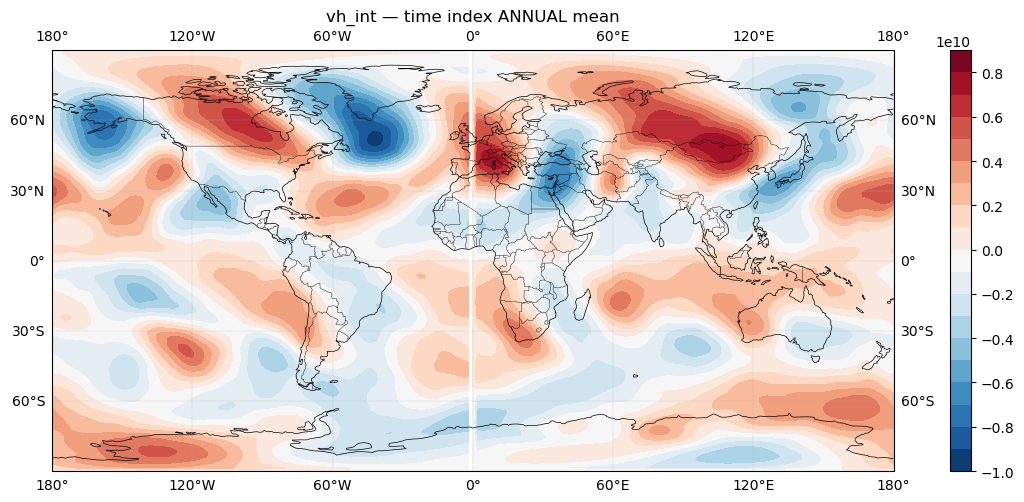

In [27]:
var=vh_int

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"

# v = var.mean(dim=["time","plev"]) ;#v_mean.mean(dim="time") ;# isel(time=t)
v = var.mean(dim="time")

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'vh_int — time index {t}')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

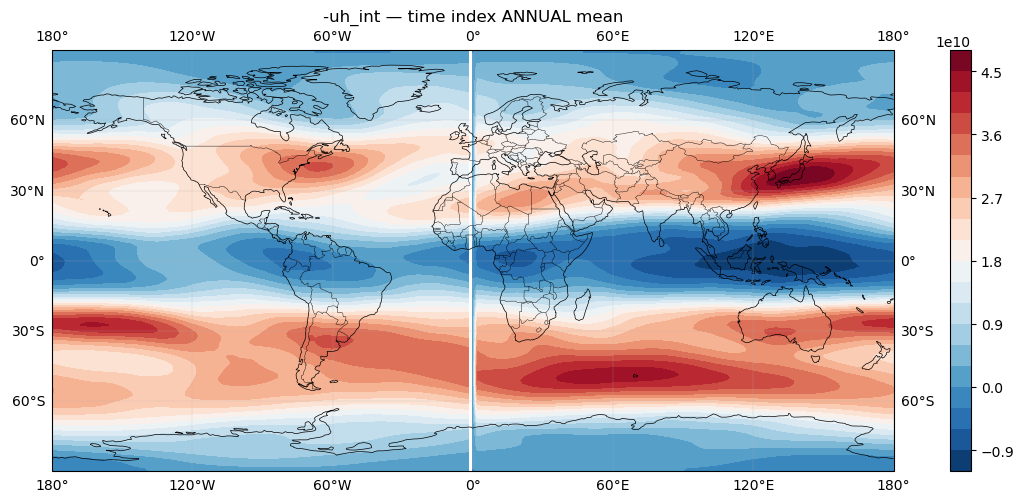

In [28]:
var=-uh_int

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"

# v = var.mean(dim=["time","plev"]) ;#v_mean.mean(dim="time") ;# isel(time=t)
v = var.mean(dim="time")

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'-uh_int — time index {t}')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

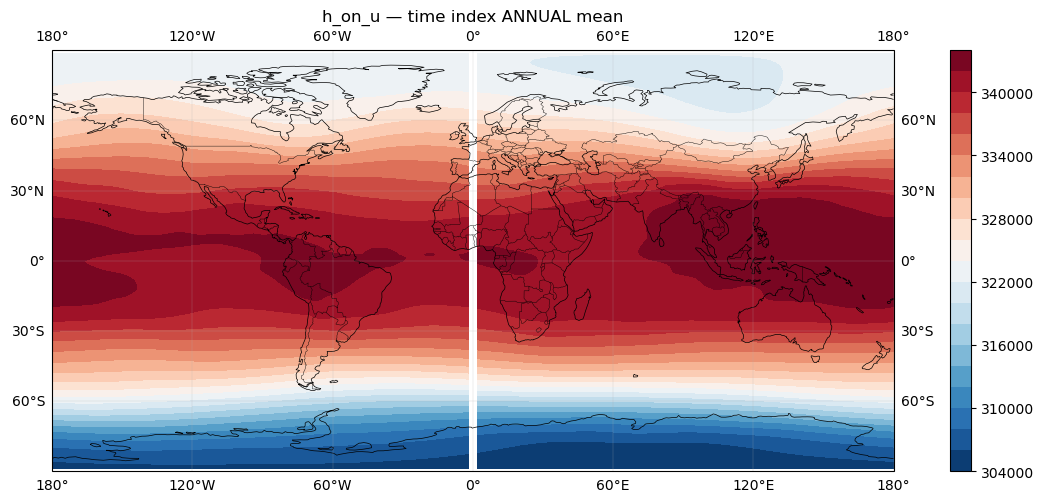

In [29]:
var=h_on_u

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"

# v = var.mean(dim=["time","plev"]) ;#v_mean.mean(dim="time") ;# isel(time=t)
v = var.mean(dim=["time","plev"])

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'h_on_u — time index {t}')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

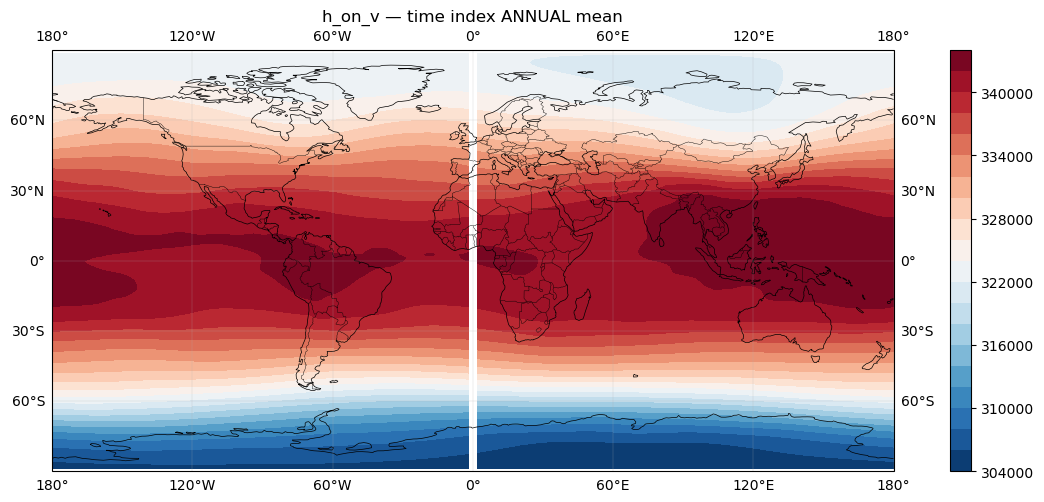

In [30]:
var=h_on_v

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"

# v = var.mean(dim=["time","plev"]) ;#v_mean.mean(dim="time") ;# isel(time=t)
v = var.mean(dim=["time","plev"])

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'h_on_v — time index {t}')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

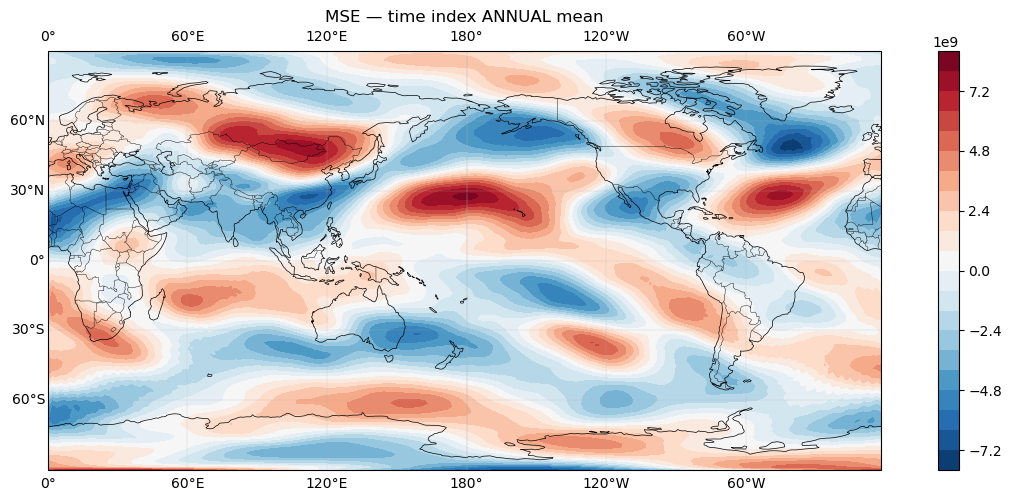

In [31]:
var=Fphi_div

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"

# v = var.mean(dim=["time","plev"]) ;#v_mean.mean(dim="time") ;# isel(time=t)
v = var.mean(dim="time")

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(180)}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'MSE — time index {t}')
plt.tight_layout()
# plt.savefig('CMIP_MSE_map.png', dpi=150)
plt.show()

In [32]:
# Compute zonal mean
Fphi_div_zonal = Fphi_div.mean(dim=['time', 'lon'])

# Find zero crossing
for i in range(len(Fphi_div_zonal.lat) - 1):
    if Fphi_div_zonal.values[i] * Fphi_div_zonal.values[i+1] < 0:
        lat1 = Fphi_div_zonal.lat.values[i]
        lat2 = Fphi_div_zonal.lat.values[i+1]
        val1 = Fphi_div_zonal.values[i]
        val2 = Fphi_div_zonal.values[i+1]
        efe_lat = lat1 - val1 * (lat2 - lat1) / (val2 - val1)
        print(f"EFE at: {efe_lat:.2f}°N")

EFE at: -88.46°N
EFE at: -63.60°N
EFE at: -30.84°N
EFE at: 5.30°N
EFE at: 28.01°N
EFE at: 56.32°N


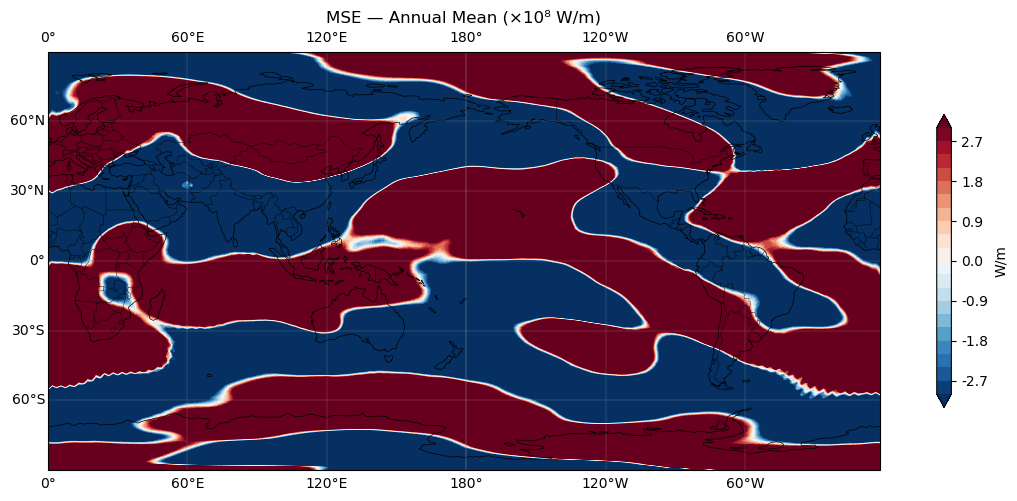

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

var = Fphi_div

# Annual mean
v = var.mean(dim="time")

# Colorbar limits
vmin = -3e8
vmax = 3e8

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(180)}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(var.lon, var.lat, v,
                 levels=np.linspace(vmin, vmax, 21), 
                 cmap='RdBu_r', 
                 extend='both',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('W/m')
cbar.formatter = plt.FuncFormatter(lambda x, p: f'{x/1e8:.1f}')
cbar.update_ticks()

ax.set_title(f'MSE — Annual Mean (×10⁸ W/m)')
plt.tight_layout()
plt.savefig('CMIP_MSE_map.png', dpi=150)
plt.show()

Using daily data and follow these steps : \
    * Calculate barotropic mass correction and correct winds \
    * Calculate vh with the full v wind field \
    * Find divergent component of vh (at each level) \
    * Integrate \
    * I do a time averaging at the end

In [34]:
print("=" * 50)
print("DIAGNOSTICS:")
print("=" * 50)
print("h range:", h.min().values, "to", h.max().values)
print("u range:", u_filled.min().values, "to", u_filled.max().values)
print("v range:", v_filled.min().values, "to", v_filled.max().values)
print()
print("uh range:", uh.min().values, "to", uh.max().values)
print("vh range:", vh.min().values, "to", vh.max().values)
print()
print("uh_int range:", uh_int.min().values, "to", uh_int.max().values)
print("vh_int range:", vh_int.min().values, "to", vh_int.max().values)
print()
print("uh_int typical value:", uh_int.mean().values)
print("vh_int typical value:", vh_int.mean().values)

DIAGNOSTICS:
h range: 274555.6 to 392601.94
u range: -35.78833 to 82.3313
v range: -25.126709 to 28.719727

uh range: -12405382.388814926 to 28222096.358543396
vh range: -8491720.65234375 to 8958541.61416626

uh_int range: -84322647625.67268 to 22908755853.77933
vh_int range: -32231374384.64254 to 28636825762.070488

uh_int typical value: -14923575638.297165
vh_int typical value: 6417382.449444051


In [35]:
print("CMIP6 pressure levels:")
print(plev.values)
print("Total column thickness:", (plev.max() - plev.min()).values, "Pa")

CMIP6 pressure levels:


NameError: name 'plev' is not defined

In [ ]:
# Compute mass flux
u_mass = (u_filled * dp).sum("plev") / g  # kg/(m·s)
v_mass = (v_filled * dp).sum("plev") / g  # kg/(m·s)

# Compute divergence using VectorWind
from windspharm.xarray import VectorWind
vw_mass = VectorWind(u_mass.mean("time"), v_mass.mean("time"))
mass_div = vw_mass.divergence()

print("Mass divergence range:", mass_div.min().values, "to", mass_div.max().values)
print("Mass divergence mean:", mass_div.mean().values)

# Plot it
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.coastlines()
im = ax.contourf(mass_div.lon, mass_div.lat, mass_div, 
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Mass divergence (kg/(m²·s))')
ax.set_title('Vertically Integrated Mass Flux Divergence')
plt.show()

In [ ]:
# # Compute kinetic energy on the original grid
# ke_u = 0.5 * u_filled**2  # on u grid
# ke_v = 0.5 * v_filled**2  # on v grid

# # Total energy = MSE + KE (each on its own grid)
# h_total_u = Cp * ta_mean + Lv * q_mean + g * z_mean + ke_u
# h_total_v = Cp * ta_mean + Lv * q_mean + g * z_mean + ke_v

# # Interpolate total energy to the respective wind grids
# # For u flux: interpolate to u grid
# h_on_u = h_total_u.interp(lat=u_mean.lat, lon=u_mean.lon, plev=u_mean.plev, method="linear")

# # For v flux: interpolate to v grid  
# h_on_v = h_total_v.interp(lat=v_mean.lat, lon=v_mean.lon, plev=v_mean.plev, method="linear")

# # Compute total energy fluxes
# uh_total = u_filled * h_on_u
# vh_total = v_filled * h_on_v

# # Sort and clean
# uh_sorted = uh_total.sortby("plev").fillna(0.0)
# vh_sorted = vh_total.sortby("plev").fillna(0.0)

# # Vertical integration
# uh_int = (uh_sorted * dp).sum("plev") / g
# vh_int = (vh_sorted * dp).sum("plev") / g

# print("With kinetic energy:")
# print("uh_int range:", uh_int.min().values, "to", uh_int.max().values)
# print("vh_int range:", vh_int.min().values, "to", vh_int.max().values)

In [ ]:
# Zonal mean of divergent meridional MSE flux
Fphi_div_zonal_cmip = Fphi_div.mean(dim=["time", "lon"])
# Fphi_div_zonal_era = Fphi_div_era5.mean(dim=["time", "longitude"])  # Your ERA5 result

# Plot both
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(Fphi_div_zonal_cmip.lat, Fphi_div_zonal_cmip, linewidth=2, label='CMIP6 (2001-2002)')
# ax.plot(Fphi_div_zonal_era.lat, Fphi_div_zonal_era, linewidth=2, label='ERA5 (2022)', linestyle='--')
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Latitude (°N)', fontsize=12)
ax.set_ylabel('Fphi_div (W/m)', fontsize=12)
ax.set_title('Zonal Mean: Divergent Meridional MSE Flux', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
var = Fphi_div

# Annual mean
v = var.mean(dim="time")

# F_phi in W/m, lat in degrees, lon in degrees on a regular grid
import numpy as np
a = 6_371_000.0
lats = v['lat'].values
lons = v['lon'].values
phi0 = 0.0  # equator
j = np.argmin(np.abs(lats - phi0))
circum = 2*np.pi*a*np.cos(np.deg2rad(lats[j]))
AET_eq = (v.isel(lat=j).mean('lon').values) * circum   # approximate zonal integral (W)
print('Cross-equatorial AET ≈', AET_eq/1e15, 'PW')